In [11]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/drive/MyDrive/data/benin-malanville.csv',parse_dates=["Timestamp"])

In [4]:
df.describe()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-02-07 12:00:30.000000512,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
min,2021-08-09 00:01:00,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,2021-11-08 06:00:45,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,2022-02-07 12:00:30,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,2022-05-09 18:00:15,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,2022-08-09 00:00:00,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN
std,NaN,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN


In [6]:
missing_report = df.isna().sum().to_frame("missing_count")
missing_report["missing_percent"] = 100 * missing_report["missing_count"] / len(df)
missing_report

,missing_count,missing_percent
Timestamp,0,0.0
GHI,0,0.0
DNI,0,0.0
DHI,0,0.0
ModA,0,0.0
ModB,0,0.0
Tamb,0,0.0
RH,0,0.0
WS,0,0.0
WSgust,0,0.0


In [8]:
#columns with >5% nulls
cols_5 = missing_report[missing_report["missing_percent"] > 5].index.tolist()
print("Columns with >5% nulls:", cols_5)

Columns with >5% nulls: ['Comments']


In [9]:
key_cols = ["GHI","DNI","DHI","ModA","ModB","WS","WSgust"]
key_cols = [c for c in key_cols if c in df.columns]

In [14]:
#Compute Z-scores
for c in key_cols:
    df[c+"_z"] = stats.zscore(df[c].astype(float), nan_policy='omit')

In [13]:
# Flag outliers (|Z|>3)
df["is_outlier"] = (df[[c+"_z" for c in key_cols]].abs() > 3).any(axis=1)
print("Outliers detected:", df["is_outlier"].sum())

Outliers detected: 7740


In [16]:
# Median imputation for key columns
for c in key_cols:
    df[c] = df[c].fillna(df[c].median())

In [ ]:
# Export cleaned CSV (never commit this file)
df.to_csv("data/benin_clean.csv", index=False)

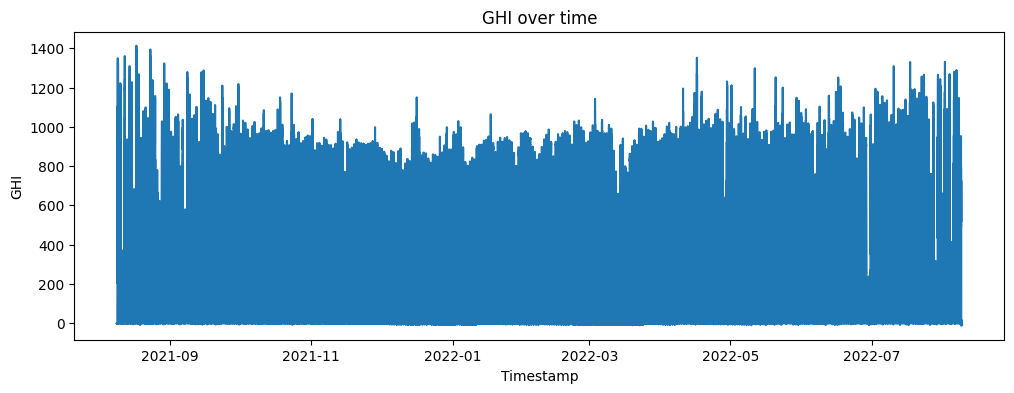

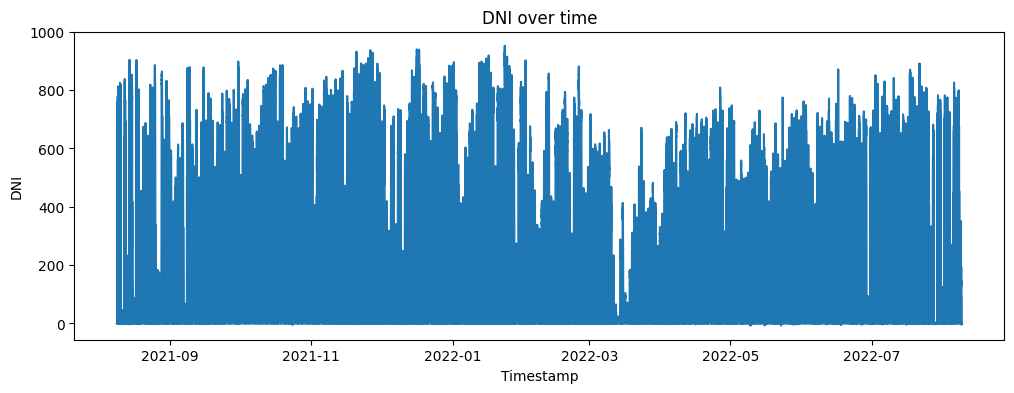

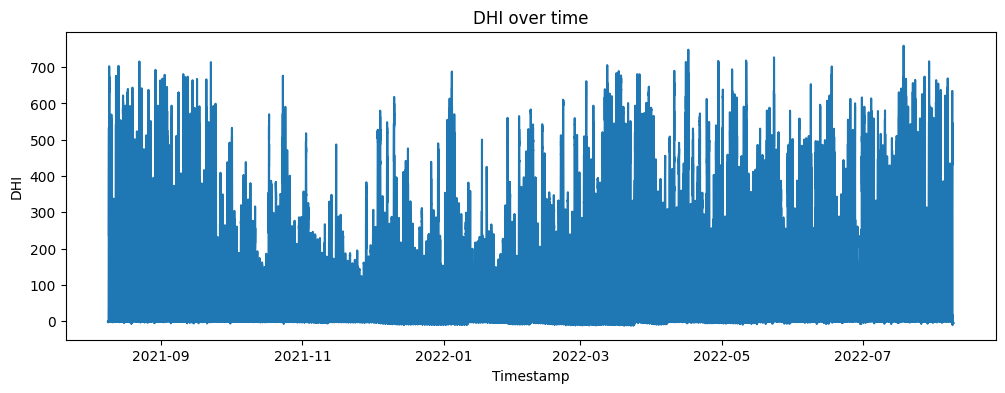

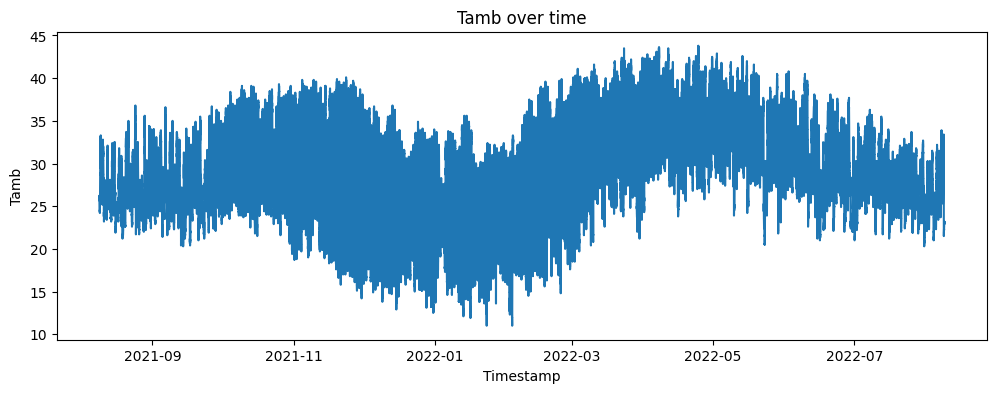

In [18]:
#Time Series Analysis
import matplotlib.pyplot as plt

plot_vars = ["GHI","DNI","DHI","Tamb"]
for col in plot_vars:
    if col in df.columns:
        plt.figure(figsize=(12,4))
        plt.plot(df["Timestamp"], df[col])
        plt.title(f"{col} over time")
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.show()


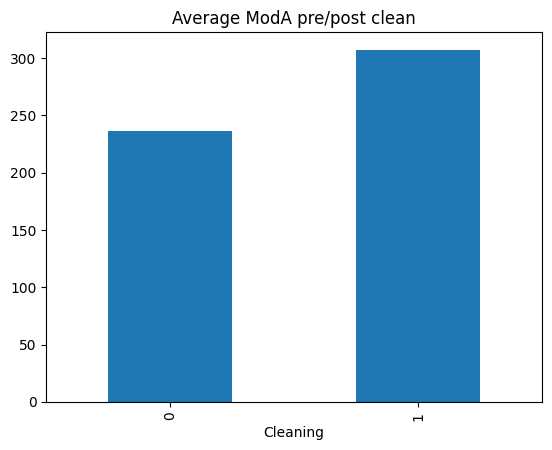

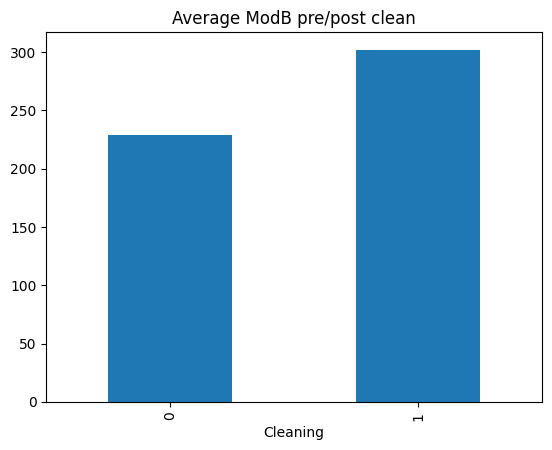

In [19]:
#Cleaning Impact (pre vs post clean)
for col in ["ModA","ModB"]:
    if col in df.columns:
        avg = df.groupby("Cleaning")[col].mean()
        avg.plot(kind="bar", title=f"Average {col} pre/post clean")
        plt.show()


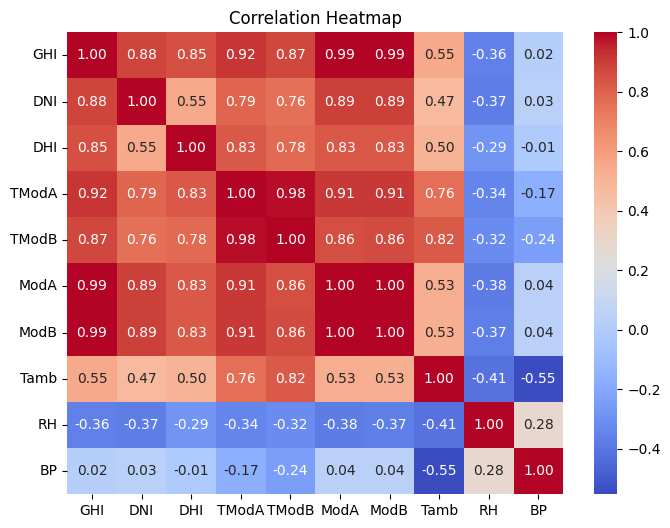

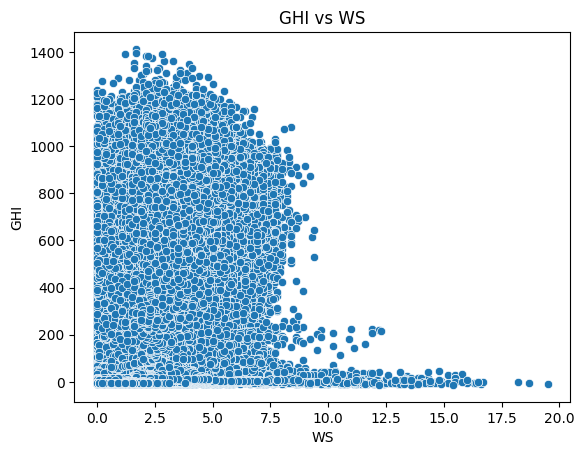

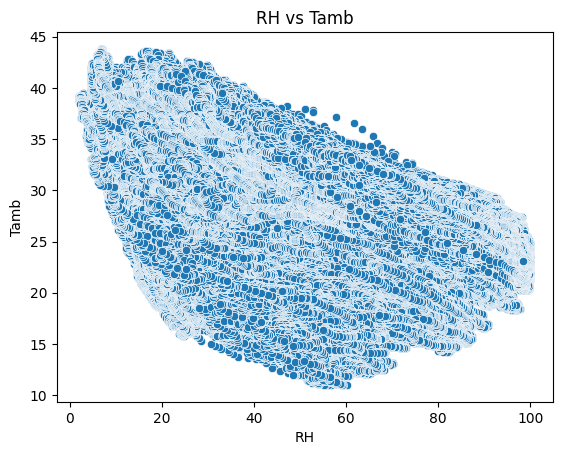

In [20]:
#Correlation & Relationship Analysis


corr_cols = ["GHI","DNI","DHI","TModA","TModB","ModA","ModB","Tamb","RH","BP"]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


sns.scatterplot(data=df, x="WS", y="GHI")
plt.title("GHI vs WS")
plt.show()

sns.scatterplot(data=df, x="RH", y="Tamb")
plt.title("RH vs Tamb")
plt.show()


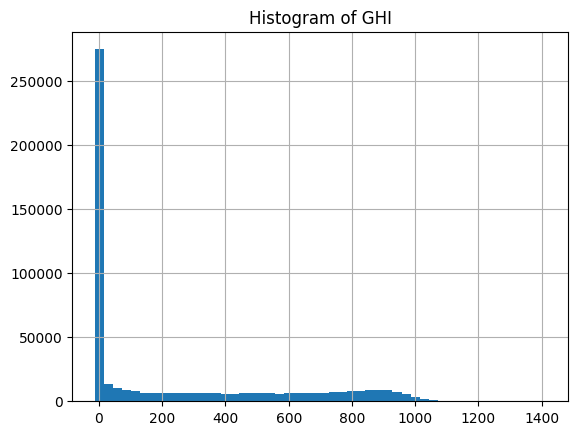

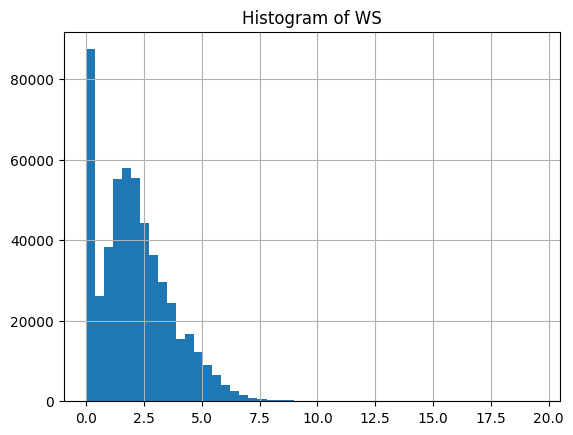

In [22]:
#Wind & Distribution Analysis
df["GHI"].hist(bins=50)
plt.title("Histogram of GHI")
plt.show()

df["WS"].hist(bins=50)
plt.title("Histogram of WS")
plt.show()


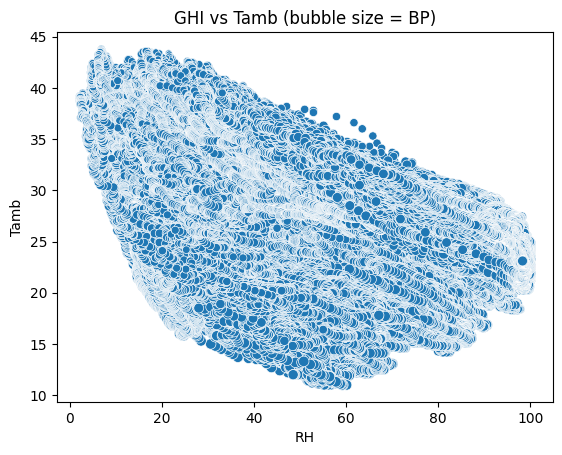

In [23]:
#Temperature Analysis (RH vs Tamb / GHI)
sns.scatterplot(data=df, x="RH", y="Tamb", size="BP", legend=False)
plt.title("GHI vs Tamb (bubble size = BP)")
plt.show()


/tmp/ipython-input-2435093286.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


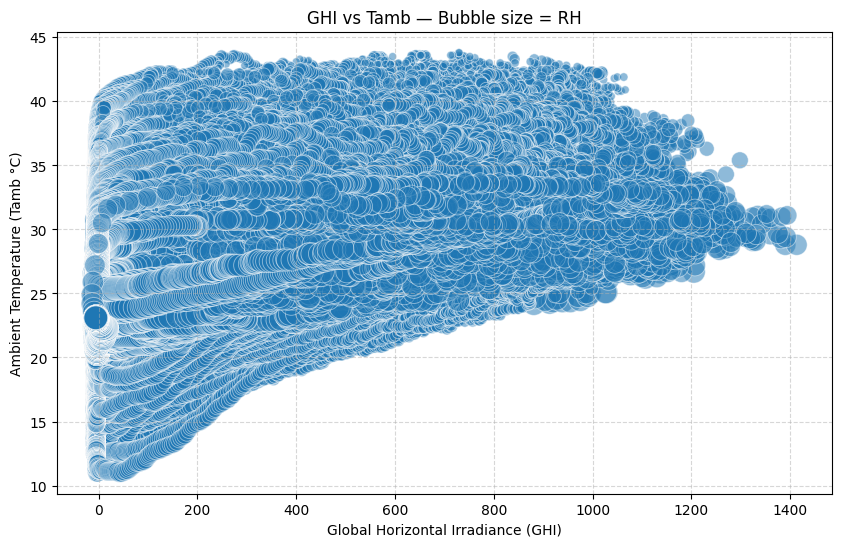

In [24]:
bubble_size_col = "RH"

if all(col in df.columns for col in ["GHI", "Tamb", bubble_size_col]):
    plt.figure(figsize=(10,6))
    sns.scatterplot(
        data=df,
        x="GHI",
        y="Tamb",
        size=bubble_size_col,
        sizes=(20, 300),
        alpha=0.5,
        palette="viridis",
        legend=False
    )
    plt.title(f"GHI vs Tamb — Bubble size = {bubble_size_col}")
    plt.xlabel("Global Horizontal Irradiance (GHI)")
    plt.ylabel("Ambient Temperature (Tamb °C)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
else:
    print("⚠️ Missing one of: GHI, Tamb, or chosen bubble variable (RH/BP)")
